# Operatii adaptive de filtrare vectoriala a imaginilor

Operatiile adaptive sunt define de schimbarea parametrilor filtrului in fiecare punct din imagine.
Deci, potential, in orice pixel din imagine, este posibil sa se aplice un filtru diferit de tot ce s-a folosit pana in acel punct.

Evident prelucrarea este de tip vecinatate, deci fereastra de filtrare va selecta valori din imaginea de prelucrat pe care le va combina.

De multe ori combinatia este de tip combinatie liniara locala, in care coeficientii de ponderare locala sunt determinati in functie de caracteristicile vecinatatii.

Vom studia doua modele de filtre: filtrul in care coeficientii de combinare sunt determinati in mod explicit in functie de distantele in spatiul de culoare dintre culorile selectate si culori de referinta si filtrul de tip LLMMSE, care se bazeaza pe minimizarea erorii patratice medii fata de imaginea ideala si care implica calculul statisticilor locale de culoare.

Vom refolosi din laboratorul trecut functiile de adaugare de zgomot pe imagini color. Nu uitati de metoda de bordare rapida a unei imagini scalare!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io,color

def add_Gaussian_noise(img,disp):
    if (np.max(img)>1):
        img = img/255.0
    zg = np.random.normal(0,disp,np.shape(img))
    imgzg = np.clip(img+zg,a_min=0,a_max=1)
    return imgzg

def add_impulsive_noise(img,p0,p1):
    if (np.max(img)>1):
        img = img/255.0
    [L,C,pl]=np.shape(img)
    Nrpix0 = int(L*C*p0)
    Nrpix1 = int(L*C*p1)
    
    for plan_curent in range(0,pl):
        numere_intregiL = np.random.randint(0,L,[Nrpix0])
        numere_intregiC = np.random.randint(0,C,[Nrpix0])
        img[numere_intregiL,numere_intregiC,plan_curent]=0
        numere_intregiL = np.random.randint(0,L,[Nrpix1])
        numere_intregiC = np.random.randint(0,C,[Nrpix1])
        img[numere_intregiL,numere_intregiC,plan_curent]=1
    
    return img

from scipy import signal
# kernel=np.zeros((2*W+1,2*W+1))
# kernel[W,W]=1
# Ybordat = signal.convolve2d(Y, kernel, mode='full', boundary='symm')

## Filtrarea adaptiva cu coeficienti determinati de distante locale intre culori

Vom porni de la structura de filtrare liniara, dar in care coeficientii de ponderare a valorilor selectate in vecinatate vor fi dependenti de pozitia absoluta in imagine, adica trecem de la filtrarea liniara clasica exprimata prin:
$$ \mathbf{g}(l,c) = \sum_{m} \sum_{n} w_{mn}\mathbf{f}(l-m,c-n)$$
la filtrarea adaptiva exprimata prin:
$$ \mathbf{g}(l,c) = \sum_{m} \sum_{n} w_{mn}(l,c)\mathbf{f}(l-m,c-n)$$
In expresia de mai sus, $w_{mn}(l,c)$ are semnificatia ponderii $w$ atasata pozitiei de coordonate relative $(m,n)$ in interiorul vecinatatii plasate cu originea in pixelul de coordonate absolute $(l,c)$.

Coeficientii $w_{mn}(l,c)$ sunt deci calculati pentru fiecare punct din vecinatate, pentru fiecare pixel din imagine. Modul de calcul trebuie sa produca valori mici pentru culorile care sunt "extreme" (foarte diferite de celelalte) si valori mari pentru culorile ce sunt "corecte" (asemanatoare cu celelalte). O metoda de abordare este de construi intai scalari care respecte principiul enuntat, scalari ce sunt apoi normalizati pentru a respecta conditia de normare a filtrelor de netezire. Astfel, se vor determina intai scalari $a_{mn}(l,c)$, din care ponderile vecinatatii sunt generate prin:
$$w_{mn}(l,c) = \frac{a_{mn}(l,c)}{\sum_i \sum_j a_{ij}(l,c)}$$

O varianta posibila de a genera scalarii $a_{mn}(l,c)$ este de a folosi principiul distantelor in spatiul de culoare dintre culoare selectata in pozitia $(m,n)$ din vecintate si un o culoare ("punct fix") calculata la nivelul vecinatatii ca estimat de incredere a culorii corecte dorite (de exemplu medianul marginal sau media marginala). Astfel coeficientii $a_{mn}(l,c)$ pot fi:
$a_{mn}(l,c) = dist(\mathbf{f}(l-m,c-n), \mathbf{f}(l,c)_{fix})^{-r}$

### Exercitiul 1. Implementati filtrul adaptiv vectorial obtinut prin abordarea "distanta".
Codati un asemenea filtru adaptiv, folosind pe rand medianul marginal si media marginala ca puncte fixe, in conditii de zgomot Gaussian, impulsiv, mixt, la diferite puteri de zgomot. Variati scalarul $r$ (cu valori pozitive). Construiti un grafic al dependentei unei masuri de calitate a imaginii filtrate de $r$, respectiv de puterea de zgomot.

Vom refolosi din laboratorul trecut scheletul functiei de median vectorial care folosea ordonare redusa dupa scalari ce reprezentau distanta la un punct fix.

In [10]:
from scipy import signal

def median_scalar(img, dim):
    if(np.max(img)>1):
        img = img/255.0
    [L,C] = np.shape(img)
    kernel = np.zeros((dim, dim))
    poz_median = dim*dim//2
    W = dim//2
    kernel[W,W] = 1
    Ybordat = signal.convolve2d(img, kernel, mode='full', boundary = 'symm')
    imgout = np.zeros((L,C))
    for l in range (0, L):
        for c in range (0, C):
            #selecteaza valori conform ferestri plasate (l,c)
            val_selectate = Ybordat[l-W+W:l+W+1+W, c-W+W:c+W+1+W]
            #combina valorile selectate
            val_sortate = np.sort(np.ndarray.flatten(val_selectate))
            #scrie rezultatul in imgout[l,c]
            imgout[l,c]=val_sortate[poz_median]
    return imgout

def median_marginal(img, dim):
    if(np.max(img)>1):
        img = img/255.0
    [L,C,pl] = np.shape(img)
    imgout = np.zeros((L,C,pl))
    for p in range (0, pl):
        imgout[:,:,p] = median_scalar(img[:,:,p], dim)

    return imgout
    

def adaptiv_dist_la_mm(img,dim,r):
    if (np.max(img)>1):
        img = img/255.0
    [L,C,pl]=np.shape(img)
    kernel=np.zeros((dim,dim))
    poz_median=dim*dim//2
    W=dim//2
    kernel[W,W]=1
    Ybordat=np.zeros((L+dim-1,C+dim-1,pl))
    for p in range(0,pl):
        Ybordat[:,:,p] = signal.convolve2d(img[:,:,p], kernel, mode='full', boundary='symm')
    
    MM=median_marginal(img,dim)
    imgout = np.zeros((L,C,pl))
    a = np.zeros((L, C))
    sum = 0;
    for l in range(0,L):
        for c in range(0,C):
            #selecteaza valori cf ferestrei plasate (l,c)
            val_selectate = Ybordat[l-W+W:l+W+1+W,c-W+W:c+W+1+W,:]
            #combina valorile selectate
            #calculez distanta de la fiecare culoare din val_selectate
            #la medianul marginal local din MM[l,c,:]
            dist=np.sum((val_selectate-MM[l,c,:])**2,axis=2)
            # distantele dist trebuie transformate in scalari "a"
            
            # 1 pe fiecare distanta, ridicam la puterea r, sa normalizam sa facem W si sa le sumam
            
            a = (1/(dist + 0.0000001)) ** r
            w = a / np.sum(a)
            # imgout[l,c,:] = np.sum(w * val_selectate)
            
            # a doua varianta
            for plan in range(0, pl):
                imgout[l,c,plan] = np.sum(w * val_selectate[:,:, plan])
                
            #scrie rezultatul in imgout[l,c]
            # imgout[l,c,:]= 
    
    print(np.max(a))
    print(np.min(a))
    
    return imgout


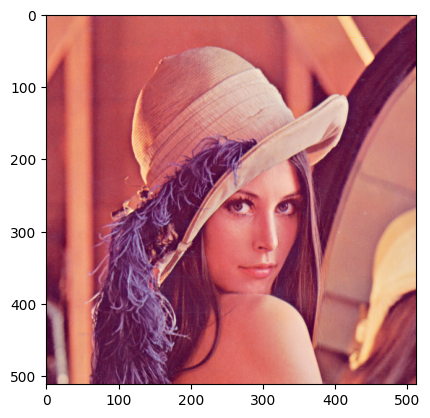

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


10000000.0
2600.3236558171316


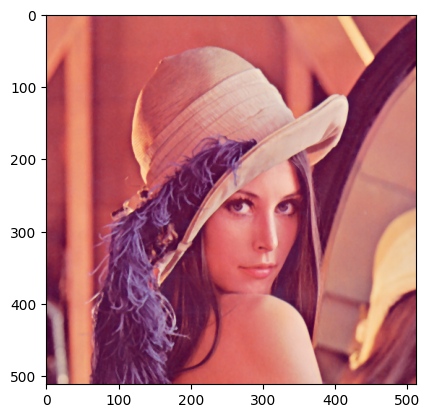

(<Figure size 640x480 with 1 Axes>,
 None)

In [11]:
img = io.imread('lena.png')
img = img[:, :, 0:3]
plt.plot(), plt.imshow(img), plt.show()

img_rez_adaptiv = adaptiv_dist_la_mm(img, 3, 1)
plt.figure(), plt.imshow(img_rez_adaptiv), plt.show()

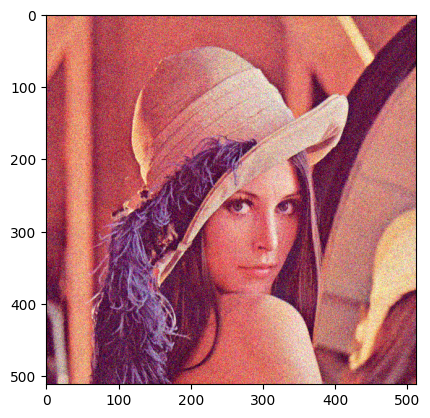

100000000000000.0
209.78744289951666


ValueError: setting an array element with a sequence.

In [16]:
def mse(img0,img):
    if (np.max(img)>1):
        img = img/255.0
    if (np.max(img0)>1):
        img0 = img0/255.0
    MSE=np.sum((img-img0)**2)/np.prod(np.shape(img))
    
    sumval=np.sum(img0**2)/np.prod(np.shape(img))
    NMSE = MSE/sumval
    
    return MSE, NMSE


img = io.imread('lena.png')
img = img[:,:,0:3] / 255.0
imgzg = add_Gaussian_noise(img, 0.1)
plt.figure(), plt.imshow(imgzg), plt.show()

mse_ = np.zeros(5)
nmse_ = np.zeros(5)

for dim in range(3,10,2):
    imout = adaptiv_dist_la_mm(imgzg, dim, 2)
    mse_[int(dim/2) - 1] = mse(img, imout)
    
    plt.figure(), plt.plot(mse_), plt.show()
    
    

## 2. Abordarea LLMMSE
Filtrarea LLMMSE (Locally-Linear Minimal Mean Squared Error) se bazeaza pe generarea imaginii filtrate ca o combinatie liniara a imaginii de filtrat si a imaginii mediate marginal.
$$\mathbf{g}(l,c) = \alpha(l,c) \mathbf{f}(l,c) + (1-\alpha(l,c)) \mathbf{\bar{f}}(l,c)$$.
Coeficientul $\alpha$ local este calculat prin:
$$alpha(l,c) = \mathbf{K}_z \times \mathbf{K}_f^{-1}(l,c)$$
$\mathbf{K}$ sunt matricile de autocovariatie ale zgomotului ($z$) si ale imaginii zgomotoase de filtrat ($f$), calculate in vecintatate.
$\mathbf{K}_z$ este considerata constanta.

### Exercitiul 2. Implementati un filtru adaptiv vectorial de tip LLMMSE.
Codati un asemenea filtru adaptiv, in conditii de zgomot Gaussian, impulsiv, mixt, la diferite puteri de zgomot. Construiti un grafic al dependentei unei masuri de calitate a imaginii filtrate de puterea de zgomot, si respectiv dimensiunile ferestrei de filtrare.

In [17]:
def adaptiv_llmmse(img,dim,r):
    if (np.max(img)>1):
        img = img/255.0
    [L,C,pl]=np.shape(img)
    kernel=np.zeros((dim,dim))
    W=dim//2
    kernel[W,W]=1
    for p in range(0,pl):
        Ybordat=np.zeros((L+dim-1,C+dim-1,pl))
        
    MM = np.zeros((L, C, pl))
    for p in range(0,pl):
        MM[:,:,p] = signal.convolve2d(img[:,:,p], np.ones((dim , dim))/(dim * dim), mode='same', boundary='symm')
    
    # calculez media marginala pentru fiecare pixel
    MM=np.zeros((L, C, pl))
    for p in range(0,pl):
        Ybordat[:,:,p] = signal.convolve2d(img[:,:,p], kernel, mode='full', boundary='symm')
    
    imgout = np.zeros((L,C,pl))
    a = np.zeros((L, C))
    sum = 0;
    for l in range(0,L):
        for c in range(0,C):
            #selecteaza valori cf ferestrei plasate (l,c)
            val_selectate = Ybordat[l-W+W:l+W+1+W,c-W+W:c+W+1+W,:]
            #combina valorile selectate
            # alpha * Ybordat[l + W, c + W, :] + (1 - alpha) ** MM[l, c]
            # alpha = Kz * (Kf ** (-1))
            
            # trebuie sa calculam covariata si cum calculam variatia?
            
            # imgout[l, c, plan] = np.sum(w, val_selectate[:,:, plan])
            
            # transform matricea val_selectate din dim * dim * 3 in (dim*dim) * 3
            # Kf = np.cov(m, rowvar=True()
            # Kf ** (-1) = np.linalg.inv(Kf)
            
            # facem acasa
    return imgout
 